Sorry for Double Resubmission this is final


---------------------------------------------------------------------------

**Project Team ID** : PTID-CDS-NOV-25-3432 \
**Project Code** : PRCP-1001-RiceLeaf \
**Project Name** : Rice Leaf Disease

Disabling GPU because of getting error during training. using CPU for training

In [1]:
# this project runs on base env in mac
# tensorflow == 2.16.2
# tensorflow_macos == 2.16.2
# tensorflow_metal == 1.1.0
# keras      == 3.11
# python     == 3.11.7
# opencv     == 4.10
# tf_keras  does not require .
# while creating brain using adam optimizer use this import --> from tensorflow.keras.optimizers import Adam (use this)
# dont use this import --> from tensorflow.keras.optimizers.legacy import Adam xxxx

import tensorflow as tf


physical_devices = tf.config.list_physical_devices('GPU')


try:

    tf.config.set_visible_devices([], 'GPU')
    logical_devices = tf.config.list_logical_devices('GPU')
    
    # print(f"Physical GPUs found: {len(physical_devices)}")
    # print(f"Logical GPUs (Used by TF): {len(logical_devices)} ")
    
except RuntimeError as e:
    print(e)

In [2]:
import pandas as pd
import numpy as np
import cv2
import os
import matplotlib.pyplot as plt
import seaborn as sns
# import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, GlobalAveragePooling2D

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

import warnings
warnings.filterwarnings('ignore')

1. Load File

In [3]:
# %pwd

# file_loc = '.'
file_loc = '/Users/rayhanfaraz/Documents/Capstone-Project/RiceLeafDisease'

classes = {
    'Bacterial leaf blight': 0,
    'Brown spot': 1,
    'Leaf smut' : 2
}

In [4]:
data = []

for class_name, label_code in classes.items():
    folder_path = os.path.join(file_loc, class_name)
    
    files = os.listdir(folder_path)
    for file in files:
        file_path = os.path.join(folder_path, file)
        data.append([file_path, class_name, label_code])

Defining df in dataframe and adding column name

Data Analysis

In [5]:
df = pd.DataFrame(data, columns = ['image_path', 'label_name', 'label_code'])

In [6]:
display(df.head())
display(df.shape)

,image_path,label_name,label_code
0,/Users/rayhanfaraz/Documents/Capstone-Project/...,Bacterial leaf blight,0
1,/Users/rayhanfaraz/Documents/Capstone-Project/...,Bacterial leaf blight,0
2,/Users/rayhanfaraz/Documents/Capstone-Project/...,Bacterial leaf blight,0
3,/Users/rayhanfaraz/Documents/Capstone-Project/...,Bacterial leaf blight,0
4,/Users/rayhanfaraz/Documents/Capstone-Project/...,Bacterial leaf blight,0


(119, 3)

In [7]:
#suffling the data  and reset index

df = df.sample(frac = 1).reset_index(drop=True)

In [8]:
df.head()

,image_path,label_name,label_code
0,/Users/rayhanfaraz/Documents/Capstone-Project/...,Brown spot,1
1,/Users/rayhanfaraz/Documents/Capstone-Project/...,Bacterial leaf blight,0
2,/Users/rayhanfaraz/Documents/Capstone-Project/...,Leaf smut,2
3,/Users/rayhanfaraz/Documents/Capstone-Project/...,Leaf smut,2
4,/Users/rayhanfaraz/Documents/Capstone-Project/...,Bacterial leaf blight,0


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119 entries, 0 to 118
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_path  119 non-null    object
 1   label_name  119 non-null    object
 2   label_code  119 non-null    int64 
dtypes: int64(1), object(2)
memory usage: 2.9+ KB


------------------------------------------------------------------
### Image Dimension analysis

In [10]:
image_stats = []

for img_path in df['image_path']:
    img = cv2.imread(img_path)

    hight, width, color  = img.shape

    image_stats.append([hight, width, color])



In [11]:
image_stats

[[897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [268, 763, 3],
 [383, 510, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [244, 617, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [197, 699, 3],
 [88, 296, 3],
 [371, 1530, 3],
 [92, 286, 3],
 [897, 3081, 3],
 [200, 250, 3],
 [897, 3081, 3],
 [124, 456, 3],
 [897, 3081, 3],
 [94, 340, 3],
 [250, 766, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [255, 946, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [71, 301, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [127, 316, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [409, 614, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [900, 1200, 3],
 [80, 376, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [216, 537, 3],
 [897, 3081, 3],
 [514, 768, 3],
 [897, 3081, 3],
 [897, 3081, 3],
 [

In [12]:
stats_df = pd.DataFrame(image_stats, columns = ['Height', 'Width','Colors'])


print(stats_df.describe())


           Height        Width  Colors
count  119.000000   119.000000   119.0
mean   707.739496  2383.638655     3.0
std    311.657582  1123.528972     0.0
min     71.000000   250.000000     3.0
25%    377.000000  1074.000000     3.0
50%    897.000000  3081.000000     3.0
75%    897.000000  3081.000000     3.0
max    900.000000  3081.000000     3.0


### images size

In [13]:
sizes = stats_df.groupby(['Height', 'Width','Colors']).size().reset_index().rename(columns = {0:'Count'})

sizes = sizes.sort_values(by=['Height','Width'], ascending=False)
print('Resolution of the images-->\n', sizes)

Resolution of the images-->
     Height  Width  Colors  Count
33     900   1200       3      1
32     897   3081       3     85
31     514    768       3      1
30     409    614       3      1
29     383    510       3      1
28     371   1530       3      1
27     323   1504       3      1
26     291    741       3      1
25     279   1480       3      1
24     268    763       3      1
23     255    946       3      1
22     250    766       3      1
21     244    617       3      1
20     233    948       3      1
19     233    565       3      1
18     224    765       3      1
17     217    562       3      1
16     216    537       3      1
15     211    948       3      1
14     200    250       3      2
13     197    699       3      1
12     193    427       3      1
11     174    503       3      1
10     170    311       3      1
9      168    359       3      1
8      127    316       3      1
7      124    456       3      1
6      104    467       3      1
5       94    

**3** Means that it is color RGB Format

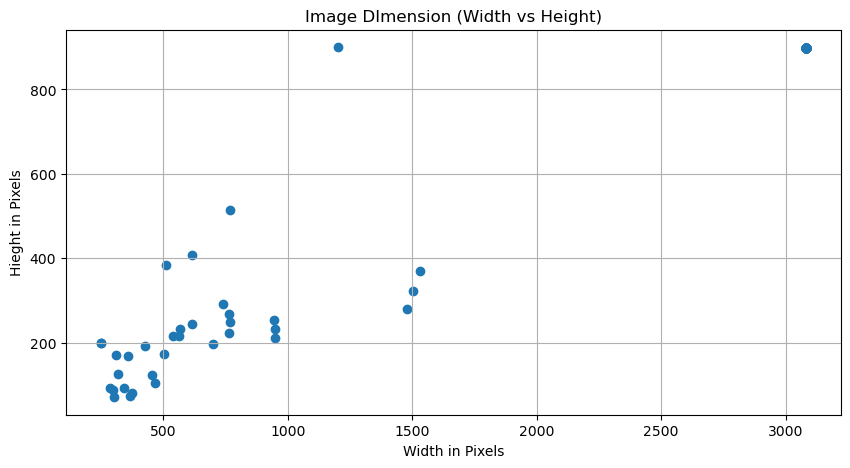

In [14]:
plt.figure(figsize=(10,5))

plt.scatter(stats_df['Width'], stats_df['Height'])
plt.title('Image DImension (Width vs Height)')
plt.xlabel('Width in Pixels')
plt.ylabel('Hieght in Pixels')
plt.grid(True)

In [15]:
img_intensity = cv2.imread(df.iloc[0]['image_path'])

print(f'\nSample Image(RGB Mean Value): {img_intensity.mean()}')
print(f'Max Pixel Value : {img_intensity.max()}')
print(f'Min Pixel Value : {img_intensity.min()}')
print(f'Imbalance ratio : {img_intensity.max() / img_intensity.min():.4f}')


Sample Image(RGB Mean Value): 144.81581542137826
Max Pixel Value : 249
Min Pixel Value : 0
Imbalance ratio : inf


Text(0, 0.5, 'Count')

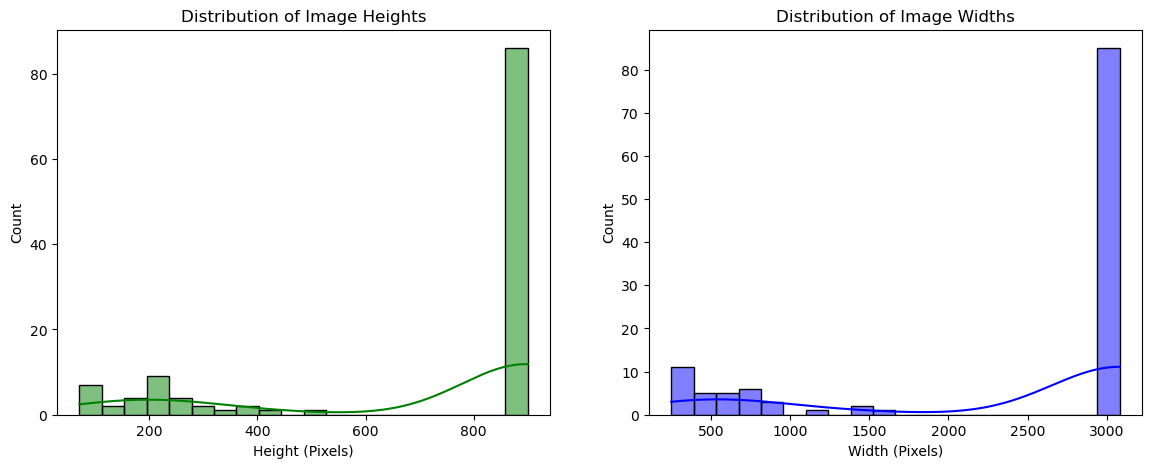

In [16]:
plt.figure(figsize=(14, 5))


plt.subplot(1, 2, 1)
sns.histplot(stats_df['Height'], kde=True, color='green', bins=20)
plt.title('Distribution of Image Heights')
plt.xlabel('Height (Pixels)')
plt.ylabel('Count')


plt.subplot(1, 2, 2)
sns.histplot(stats_df['Width'], kde=True, color='blue', bins=20)
plt.title('Distribution of Image Widths')
plt.xlabel('Width (Pixels)')
plt.ylabel('Count')

### Final Analysis of dimension

* 85 images have high resolution dimension of 897 x 3081.
* Majority of images are panoramic ( width is 3x larger than height )
* Some image are small dimension 71 x 301
* Images are highly Imbalance.

### EDA

Text(0.5, 0, 'Disease Type')

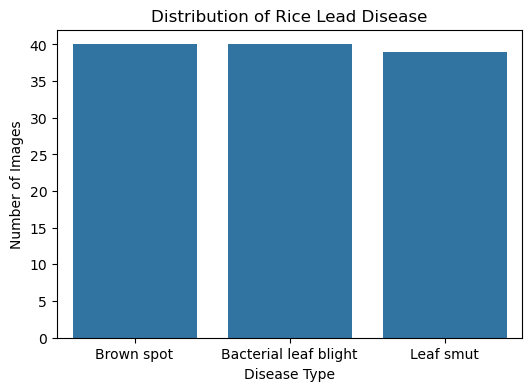

In [17]:
plt.figure(figsize=(6,4))

sns.countplot(x = 'label_name',  data=df)
plt.title('Distribution of Rice Lead Disease')
plt.ylabel('Number of Images')
plt.xlabel('Disease Type')

Although the problem statement mentions 120 images ,



* Bacterial Leaf Blight: 40 images (33.6%)
* Brown Spot: 40 images (33.6%)
* Leaf Smut: 39 images (32.8%)

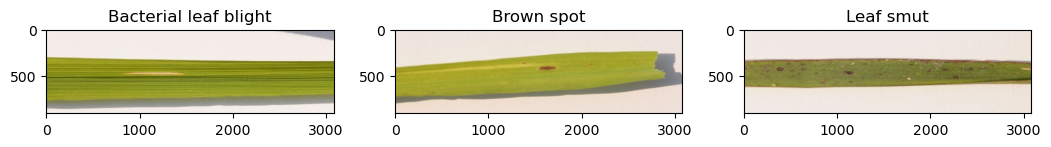

In [18]:
plt.figure(figsize=(14,6))


for i , category in enumerate(classes.keys()):

    img_category_wise = df[df['label_name'] == category]['image_path'].values[3]
    image = plt.imread(img_category_wise)
    plt.subplot(3,4,i+1)
    plt.title(category)
    plt.imshow(image)
    plt.tight_layout()
    plt.axis
plt.show()

Checking Extension of all file, and making sure all image are in jpg

In [19]:
df['extension'] = df['image_path'].apply(lambda x: x.split('.')[-1].lower())

print('file extension')
print(df['extension'].value_counts())

file extension
extension
jpg    119
Name: count, dtype: int64


### Data Preparetion (split & Augmentation)

In [20]:
from sklearn.model_selection import train_test_split

train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42, stratify= df['label_name'])

print(f'train_df shape : ', train_df.shape)
print(f'valid_df shape : ', valid_df.shape)

train_df shape :  (95, 4)
valid_df shape :  (24, 4)


In [21]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)
train_generator = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    x_col='image_path',
    y_col='label_name',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=True
)


valid_datagen = ImageDataGenerator(rescale=1./255)

valid_generator = valid_datagen.flow_from_dataframe(
    dataframe=valid_df,
    x_col='image_path',
    y_col='label_name',
    target_size=(224, 224),
    batch_size=16,
    class_mode='categorical',
    shuffle=False
)

Found 95 validated image filenames belonging to 3 classes.
Found 24 validated image filenames belonging to 3 classes.


Handling Class Imbalance (Class Weighting):

* The imbalance ratio was negligible (1.02:1),implemented Class Weighting during training to penalize misclassifications of the minority class ('Leaf Smut') more heavily.
* This strategy ensures the model does not become biased toward the majority classes ('Bacterial Blight' and 'Brown Spot') and demonstrates a robust approach for handling skewed datasets without the computational cost of oversampling.

### Model Creation (CNN)

In [22]:
# Model Creation (CNN)

# from tensorflow.keras.optimizers.legacy import Adam

model = Sequential([
    # First Block
    Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
    MaxPooling2D(pool_size=(2, 2)),

    # second block
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    # third block
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D(pool_size=(2, 2)),

    #flatten()
    Flatten(),

    # classification head
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(3, activation='softmax')
])


from tensorflow.keras.optimizers import Adam
model.compile(optimizer=Adam(learning_rate = 0.001), loss='categorical_crossentropy', metrics=['accuracy'])


model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,245,443 (84.86 MB)

 Trainable params: 22,245,443 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

### Model Training

In [23]:
from tensorflow.keras.callbacks import ReduceLROnPlateau

lr_On_Plateau_model = ReduceLROnPlateau(
    monitor = 'val_accuracy',
    factor = 0.5,
    patience = 3,
    min_lr = 1e-6,
    verbose = 1
)

In [24]:
history = model.fit(
    train_generator,
    validation_data=valid_generator,
    epochs = 30,
    callbacks = [lr_On_Plateau_model]
    )

Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 774ms/step - accuracy: 0.3158 - loss: 4.6960 - val_accuracy: 0.3333 - val_loss: 1.1476 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 5s 771ms/step - accuracy: 0.3789 - loss: 1.1150 - val_accuracy: 0.3333 - val_loss: 1.0811 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4211 - loss: 1.1050 - val_accuracy: 0.3750 - val_loss: 1.0910 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.3684 - loss: 1.0760 - val_accuracy: 0.4583 - val_loss: 1.1247 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 1s/step - accuracy: 0.4842 - loss: 1.0034 - val_accuracy: 0.3333 - val_loss: 1.0918 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step - accuracy: 0.5158 - loss: 1.0142 - val_accuracy: 0.5000 - val_loss: 1.0471 - learning_rate: 0.0010
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 6s 978ms/step - accuracy: 0.5263 - loss: 0.9467 - val_accuracy: 0.5000 - val

Evaluation Report

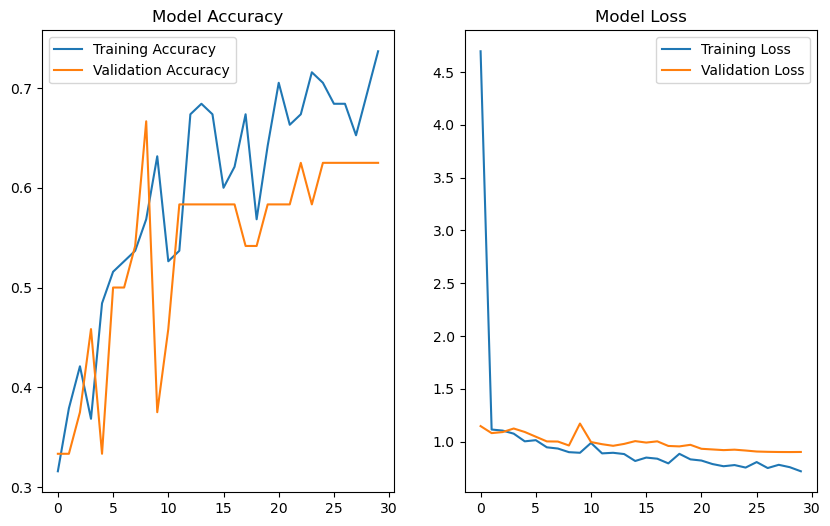

In [25]:
plt.figure(figsize=(10,6))

# 1. Plotting Accuracy

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# 2. PLotting Loss

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

* The training graphs reveal significant spikes in validation accuracy.
* This is characteristic of training on small datasets (High Variance).
* While the model successfully learns patterns evident from the decreasing loss the fluctuations confirm that the validation set (24 images) is sensitive to individual misclassifications.

In [26]:
valid_generator.reset()

# classification reoprt
y_pred = model.predict(valid_generator)
y_pred_classes = np.argmax(y_pred, axis=1)

#true labels

y_true = valid_generator.classes
class_labels = list(valid_generator.class_indices.keys())

# confusion matrix
print(confusion_matrix(y_true, y_pred_classes))

# classification report
print('\n classification report')
print(classification_report(y_true, y_pred_classes, target_names=list(class_labels)))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 191ms/step
[[7 0 1]
 [3 2 3]
 [0 2 6]]

 classification report
                       precision    recall  f1-score   support

Bacterial leaf blight       0.70      0.88      0.78         8
           Brown spot       0.50      0.25      0.33         8
            Leaf smut       0.60      0.75      0.67         8

             accuracy                           0.62        24
            macro avg       0.60      0.62      0.59        24
         weighted avg       0.60      0.62      0.59        24



The Convolutional Neural Network (CNN) achieved an Validation Accuracy of 62%. 

A detailed analysis of the performance metrics on the validation set reveals significant variance in the model's ability to detect specific disease types:

* Bacterial Leaf Blight: The model showed excellent sensitivity with a Recall of 0.88, meaning it successfully identified the bacterial blight cases. The Precision of 0.70 
* Leaf Smut: The model performed moderately well, achieving a balanced Precision of 0.60 and Recall of 0.75 (f1-score : 0.67).
* Brown Spot: This was the most challenging class, with a Precision of 0.50 but a Recall of only 0.25 (f1-score : 0.33). This suggests the model rarely identifies Brown Spot correctly, though when it does, it is accurate.

### Error Analysis

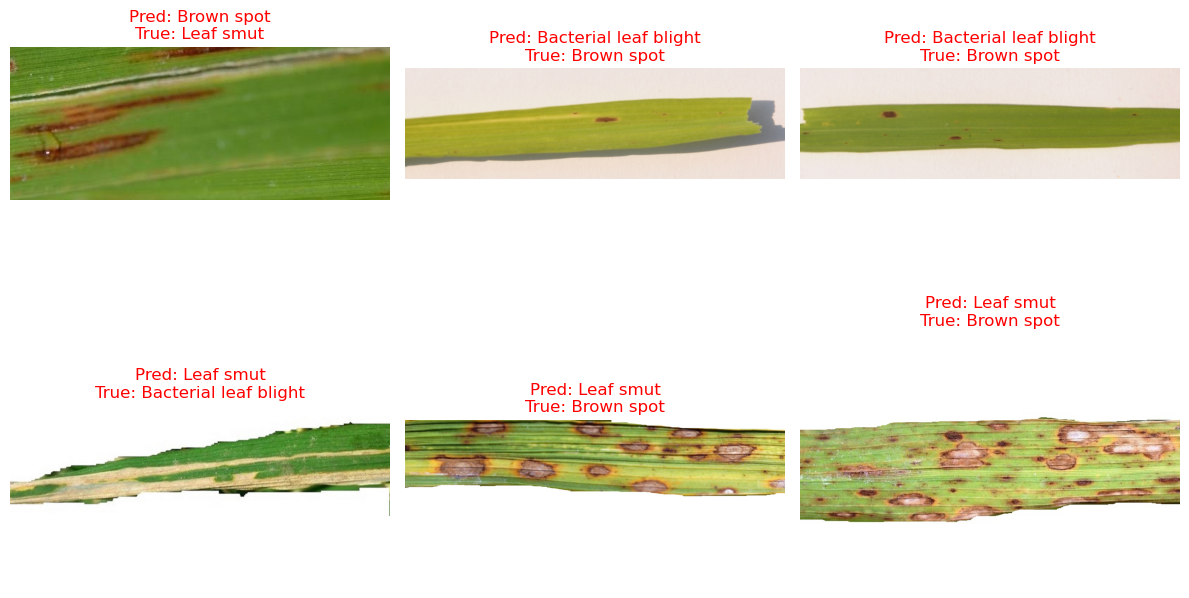

In [27]:
y_true = np.array(valid_generator.classes)

errors = (y_pred_classes != y_true)

x_val_filenames = valid_generator.filenames

# this does is filter the data to get only the mistakes
x_val_errors = [x_val_filenames[i] for i in range(len(errors)) if errors[i]]

# get the integrer class Id error like(0,1,2,3...)
y_pred_classes_errors = y_pred_classes[errors]


y_true_errors = y_true[errors]


#display item

if len(x_val_errors) > 0:
  plt.figure(figsize=(12,8))
    
  for i in range(min(6, len(x_val_errors))):
    plt.subplot(2,3,i+1)
      
    img = plt.imread(x_val_errors[i])
    plt.imshow(img)

    pred_label = y_pred_classes_errors[i]
    true_label = y_true_errors[i]
      
    plt.title(f"Pred: {class_labels[pred_label]}\nTrue: {class_labels[true_label]}", color='red')
    plt.axis('off')
  plt.tight_layout()
  plt.show()
else:
  print('no errors found')

In [28]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.models import Model


### Model - 2 : MobileNetV2

In [29]:

from tensorflow.keras.applications import MobileNetV2


base_model_2 = MobileNetV2(
    input_shape=(224, 224, 3), 
    include_top=False, 
    weights='imagenet'
)


In [30]:
base_model_2.trainable = False

In [31]:
x = base_model_2.output
x = GlobalAveragePooling2D()(x) 
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(3, activation='softmax')(x)

In [32]:

# Build Model
model_mobilenet = Model(inputs=base_model_2.input, outputs=output)

# Compile

model_mobilenet.compile(optimizer=Adam(learning_rate=0.001), 
                        loss='categorical_crossentropy', 
                        metrics=['accuracy'])

model_mobilenet.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,339 (9.24 MB)

 Trainable params: 164,355 (642.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [33]:

#  Training MobileNet
print("\nTraining Transfer Learning Model (MobileNetV2)...")
history_mobile = model_mobilenet.fit(
    train_generator,
    validation_data=valid_generator,
    epochs=30,
    callbacks=[lr_On_Plateau_model] 
)


Training Transfer Learning Model (MobileNetV2)...
Epoch 1/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 7s 818ms/step - accuracy: 0.4000 - loss: 1.3425 - val_accuracy: 0.7083 - val_loss: 0.7277 - learning_rate: 0.0010
Epoch 2/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 572ms/step - accuracy: 0.6211 - loss: 0.8756 - val_accuracy: 0.7083 - val_loss: 0.7094 - learning_rate: 0.0010
Epoch 3/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 564ms/step - accuracy: 0.6632 - loss: 0.7678 - val_accuracy: 0.7083 - val_loss: 0.5113 - learning_rate: 0.0010
Epoch 4/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 582ms/step - accuracy: 0.7895 - loss: 0.5520 - val_accuracy: 0.7500 - val_loss: 0.4159 - learning_rate: 0.0010
Epoch 5/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 576ms/step - accuracy: 0.7789 - loss: 0.4412 - val_accuracy: 0.7917 - val_loss: 0.4150 - learning_rate: 0.0010
Epoch 6/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 4s 599ms/step - accuracy: 0.8737 - loss: 0.3631 - val_accuracy: 0.9167 - val_loss: 0.3231 - learning_rate: 0.0010
Epoch 7/30
6/6 ━━━━━━━━━━━━━━━━━━━━ 3s 580ms/step

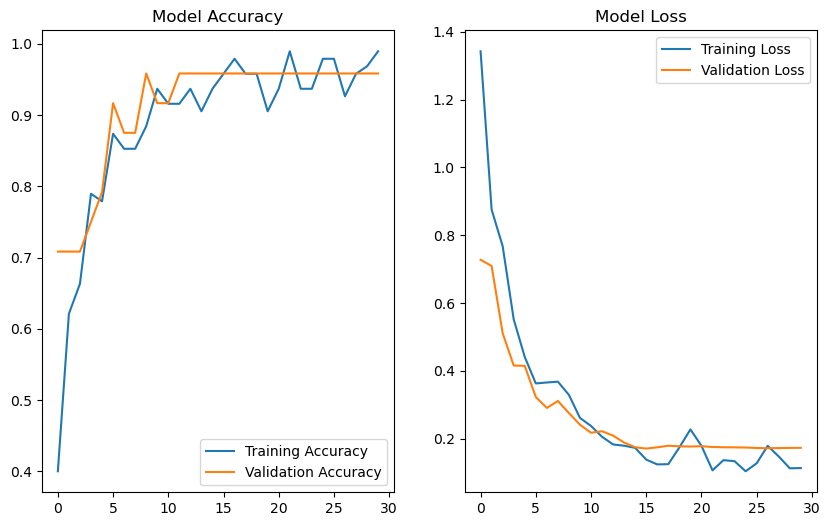

In [34]:
plt.figure(figsize=(10,6))

# Plotting Accuracy

plt.subplot(1,2,1)
plt.plot(history_mobile.history['accuracy'], label='Training Accuracy')
plt.plot(history_mobile.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.legend()

# PLotting Loss

plt.subplot(1, 2, 2)
plt.plot(history_mobile.history['loss'], label='Training Loss')
plt.plot(history_mobile.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.legend()

plt.show()

In [35]:
print("Analyzing MobileNetV2 Errors...")


valid_generator.reset()

# predictions from the MobileNet model

Y_pred_mobile = model_mobilenet.predict(valid_generator) 
y_pred_classes_mobile = np.argmax(Y_pred_mobile, axis=1)

# True Labels
y_true = np.array(valid_generator.classes)
class_labels = list(valid_generator.class_indices.keys())

# Classification Report for MobileNet
print("\n--- MobileNetV2 Classification Report ---")
print(classification_report(y_true, y_pred_classes_mobile, target_names=class_labels))

# Confusion Matrix
print("\n--- MobileNetV2 Confusion Matrix ---")
print(confusion_matrix(y_true, y_pred_classes_mobile))

# Finding the specific Errors
errors_mobile = (y_pred_classes_mobile != y_true)


x_val_filenames = valid_generator.filenames
x_val_errors_mobile = [x_val_filenames[i] for i in range(len(errors_mobile)) if errors_mobile[i]]
y_pred_errors_mobile = y_pred_classes_mobile[errors_mobile]
y_true_errors_mobile = y_true[errors_mobile]

print(f"\nTotal Errors by MobileNetV2: {len(x_val_errors_mobile)}")

Analyzing MobileNetV2 Errors...
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 592ms/step

--- MobileNetV2 Classification Report ---
                       precision    recall  f1-score   support

Bacterial leaf blight       1.00      0.88      0.93         8
           Brown spot       1.00      1.00      1.00         8
            Leaf smut       0.89      1.00      0.94         8

             accuracy                           0.96        24
            macro avg       0.96      0.96      0.96        24
         weighted avg       0.96      0.96      0.96        24


--- MobileNetV2 Confusion Matrix ---
[[7 0 1]
 [0 8 0]
 [0 0 8]]

Total Errors by MobileNetV2: 1


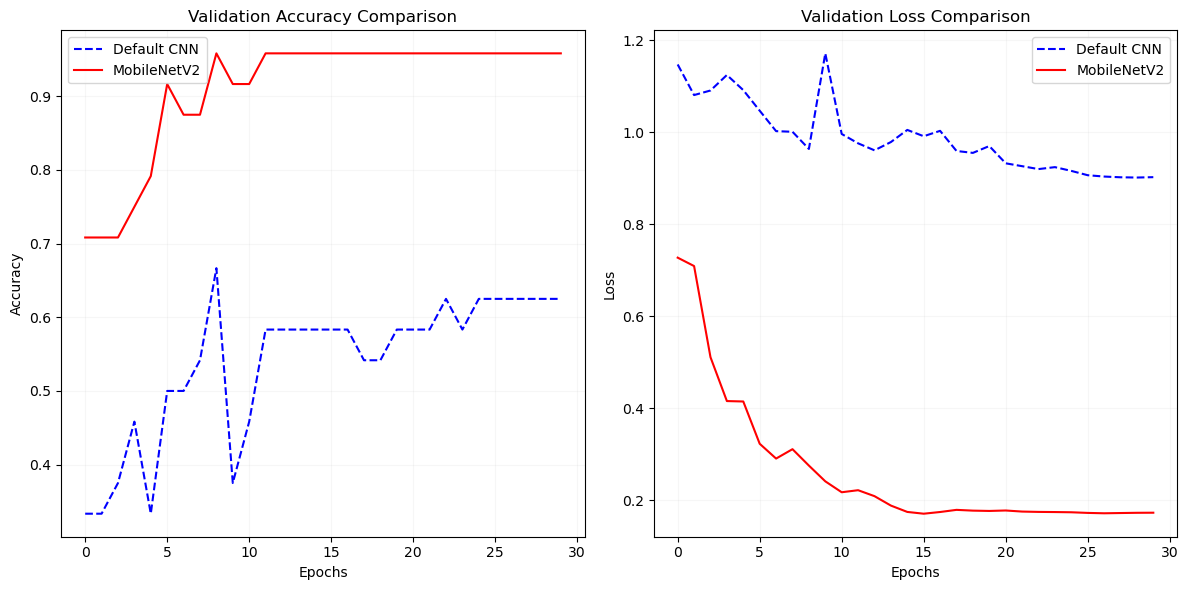

In [39]:
plt.figure(figsize=(12, 6))

# Plot Accuracy Comparison
plt.subplot(1, 2, 1)

plt.plot(history.history['val_accuracy'], label='Default CNN', color='blue', linestyle='--')
plt.plot(history_mobile.history['val_accuracy'], label='MobileNetV2', color='red')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.1)

# Plot Loss Comparison
plt.subplot(1, 2, 2)

plt.plot(history.history['val_loss'], label='Default CNN', color='blue', linestyle='--')
plt.plot(history_mobile.history['val_loss'], label='MobileNetV2', color='red')

plt.title('Validation Loss Comparison')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.1)

plt.tight_layout()
plt.show()

In [41]:
acc_cnn = max(history.history['val_accuracy'])
loss_cnn = min(history.history['val_loss'])

# Get the final validation scores for Model 2
acc_mobile = max(history_mobile.history['val_accuracy'])
loss_mobile = min(history_mobile.history['val_loss'])

# Create the Comparison Table
comparison_df = pd.DataFrame({
    'Model Name': ['Default CNN (Baseline)', 'MobileNetV2 (Transfer Learning)'],
    'Best Val Accuracy': [f"{acc_cnn:.2%}", f"{acc_mobile:.2%}"],
    'Best Val Loss': [f"{loss_cnn:.4f}", f"{loss_mobile:.4f}"],
    'Parameters': [model.count_params(), model_mobilenet.count_params()]
})

print("--- MODEL ARCHITECTURE COMPARISON RESULTS ---")
print(comparison_df)

--- MODEL ARCHITECTURE COMPARISON RESULTS ---
                        Model Name Best Val Accuracy Best Val Loss  Parameters
0           Default CNN (Baseline)            66.67%        0.9018    22245443
1  MobileNetV2 (Transfer Learning)            95.83%        0.1711     2422339


### Final Conclusion is that MobileNetV2 Model Achieve 95% of accuracy with 0.1711 validation loss

### Best fit model for this is **MobileNetV2 Model**